**Importing Libraries and Preparing the Dataset**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split # Used later for loss plotting

import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load the pre-split datasets
try:
    train_data = pd.read_csv('train_energy_data.csv')
    test_data = pd.read_csv('test_energy_data.csv')
except FileNotFoundError:
    print("Error: Make sure 'train_energy_data.csv' and 'test_energy_data.csv' are uploaded to Colab.")

# Clean up column names by stripping whitespace
train_data.columns = train_data.columns.str.strip()
test_data.columns = test_data.columns.str.strip()

# Define features (X) and label (y) for training set
X_train = train_data.drop('Energy Consumption', axis=1)
y_train = train_data['Energy Consumption']

# Define features (X) and label (y) for test set
X_test = test_data.drop('Energy Consumption', axis=1)
y_test = test_data['Energy Consumption']

print("--- Data Loading and Split Summary ---")
print("Training Data Head:")
print(X_train.head())
print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

--- Data Loading and Split Summary ---
Training Data Head:
  Building Type  Square Footage  Number of Occupants  Appliances Used  \
0   Residential            7063                   76               10   
1    Commercial           44372                   66               45   
2    Industrial           19255                   37               17   
3   Residential           13265                   14               41   
4    Commercial           13375                   26               18   

   Average Temperature Day of Week  
0                29.84     Weekday  
1                16.72     Weekday  
2                14.30     Weekend  
3                32.82     Weekday  
4                11.92     Weekday  

Training set size: 1000
Test set size: 100


This code starts by importing all the essential Python libraries needed for data analysis and machine learning — such as pandas and NumPy for handling data, matplotlib and seaborn for creating visualizations, and several tools from scikit-learn for preprocessing, modeling, and evaluation. To keep the output clean, warnings are turned off, and a random seed is set to make sure results can be reproduced. The script then loads two datasets, train_energy_data.csv and test_energy_data.csv, while also checking if the files exist before proceeding. Once loaded, it tidies up the column names by removing any extra spaces. The data is then split into features (the input variables) and a target variable called “Energy Consumption.” Finally, the code prints a quick summary showing the first few rows of the training data along with how many samples are in the training and test sets.

**Exploratory Data Analysis (EDA): Statistical Summary and Missing Values**

In [25]:
# Statistical values for the training data
print("--- Statistical Summary of Training Data ---")
print(train_data.describe().T)

# Check for missing values
print("\n--- Missing Values in Training Data ---")
print(train_data.isnull().sum())

--- Statistical Summary of Training Data ---
                      count         mean           std      min         25%  \
Square Footage       1000.0  25462.38800  14294.554000   560.00  13169.7500   
Number of Occupants  1000.0     48.37200     29.061972     1.00     22.0000   
Appliances Used      1000.0     25.60600     14.105166     1.00     13.0000   
Average Temperature  1000.0     22.61139      7.139943    10.05     16.4750   
Energy Consumption   1000.0   4166.25257    933.313064  1683.95   3509.4825   

                           50%       75%       max  
Square Footage       25477.000  37446.25  49997.00  
Number of Occupants     47.000     73.25     99.00  
Appliances Used         26.000     38.00     49.00  
Average Temperature     22.815     28.85     34.99  
Energy Consumption    4175.730   4863.85   6530.60  

--- Missing Values in Training Data ---
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature  

This section performs a quick exploratory analysis of the training dataset. It first prints out a statistical summary of all numerical features, including metrics such as mean, standard deviation, minimum, and maximum values. This helps in understanding the distribution and scale of the data. Next, the code checks for any missing values in the dataset to identify potential data quality issues that might need to be handled before model training.

Data Visualization: Distributions and Categorical Feature Analysis

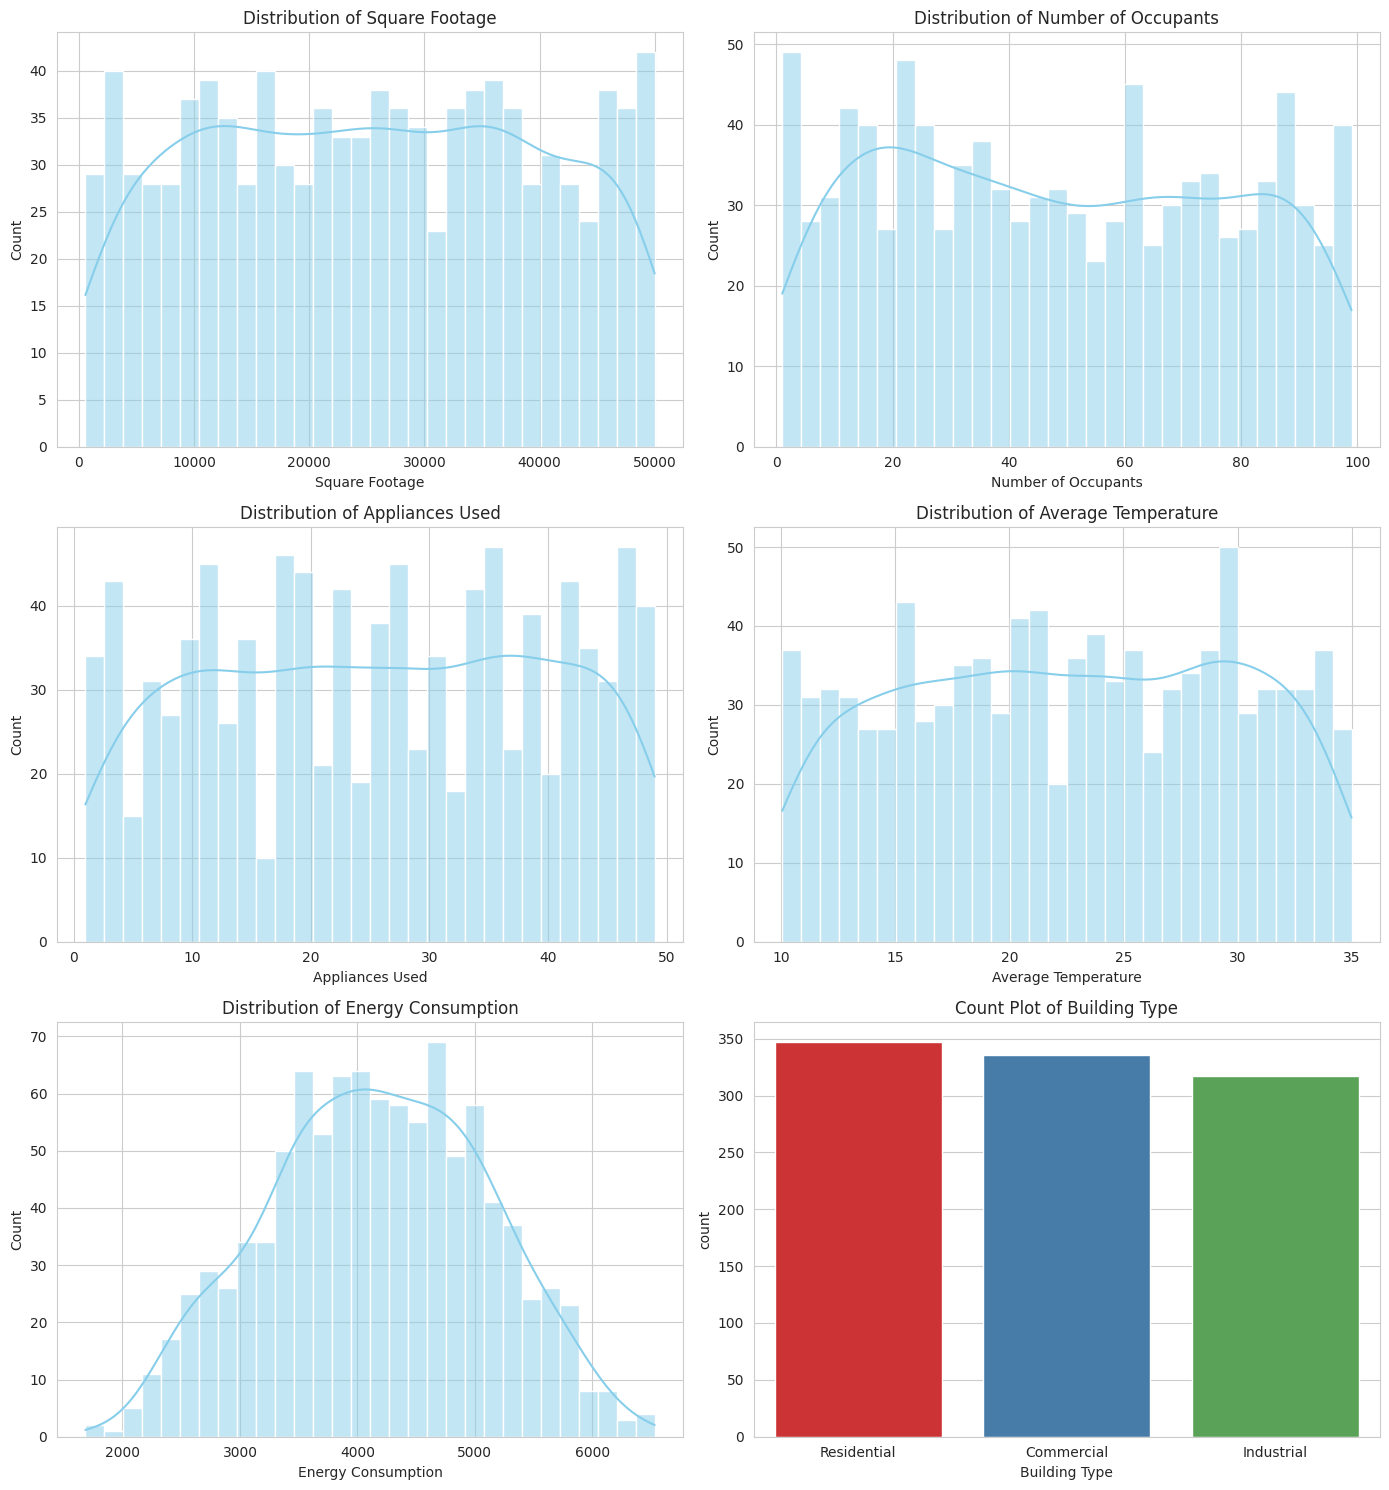

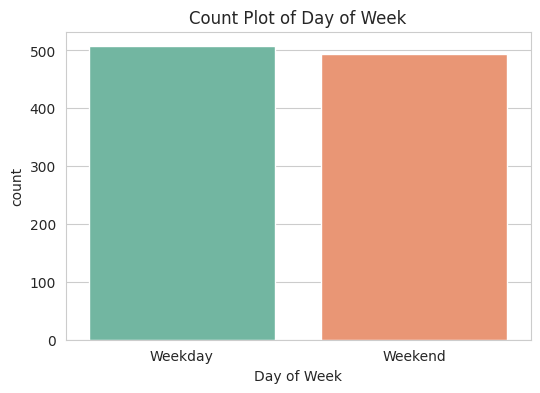

In [15]:
sns.set_style('whitegrid')

# Continuous Features and Label (Histograms)
cont_cols = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Energy Consumption']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    sns.histplot(train_data[col], kde=True, ax=axes[i], bins=30, color='skyblue')
    axes[i].set_title(f'Distribution of {col}')

# Categorical Features (Count Plots)
sns.countplot(x='Building Type', data=train_data, ax=axes[5], palette='Set1')
axes[5].set_title('Count Plot of Building Type')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='Day of Week', data=train_data, palette='Set2')
plt.title('Count Plot of Day of Week')
plt.show()

This section focuses on visualizing the key features of the training dataset to better understand their distributions and patterns. Using Seaborn’s clean white grid style, it first plots histograms with KDE (Kernel Density Estimation) for continuous variables such as Square Footage, Number of Occupants, Appliances Used, Average Temperature, and Energy Consumption. These plots help visualize how each variable is distributed and whether any skewness or outliers exist. Next, the code uses count plots to analyze categorical features specifically, the Building Type and Day of Week showing how often each category appears in the dataset. This visual exploration provides valuable insights into data balance and potential trends before moving on to model training.

**Correlation Analysis and Feature Relationships**

--- Pearson Correlation Coefficient (PCC) with Energy Consumption ---
Energy Consumption     1.000000
Square Footage         0.774873
Number of Occupants    0.354485
Appliances Used        0.312792
Average Temperature   -0.034487
Name: Energy Consumption, dtype: float64


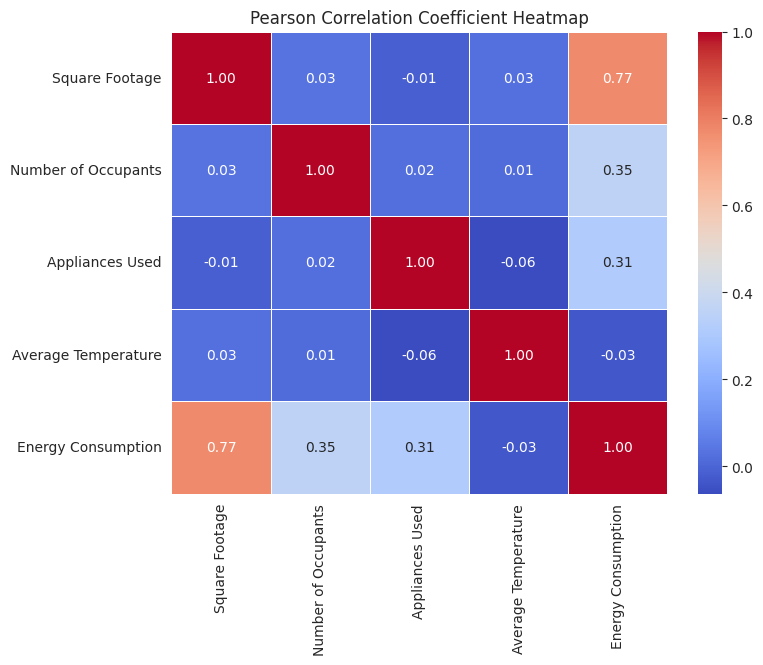

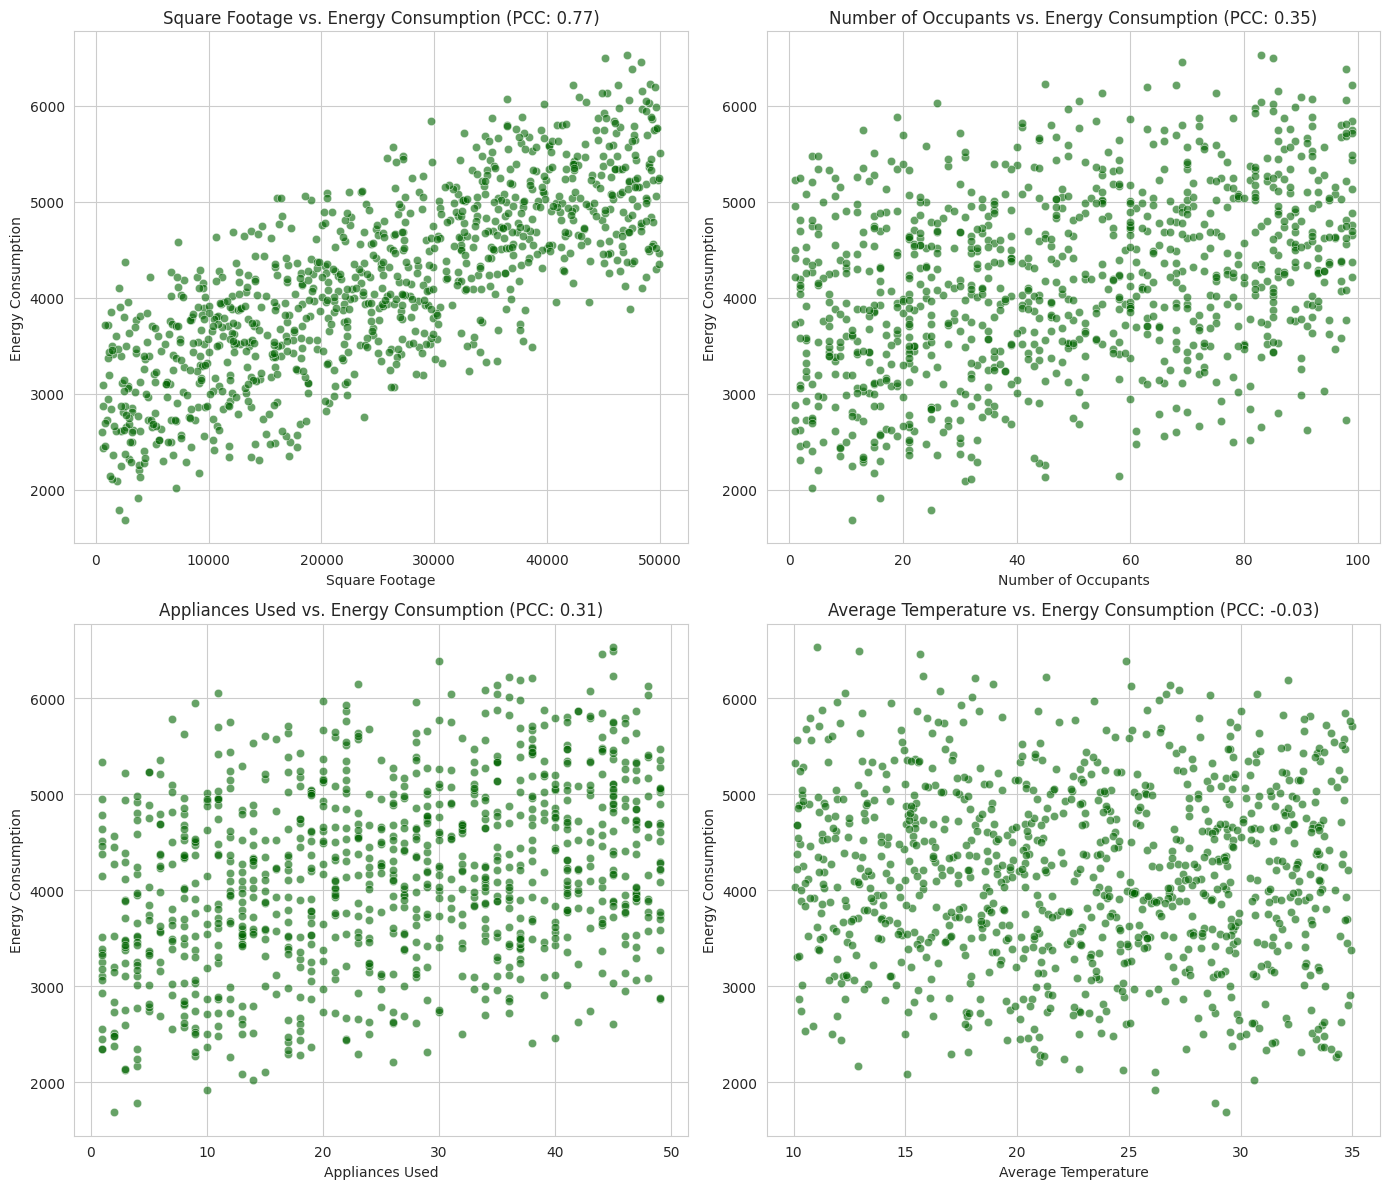

In [16]:
# Create a temporary DataFrame for correlation (excluding categorical features)
numeric_train_data = train_data.select_dtypes(include=np.number)
corr_matrix = numeric_train_data.corr()

print("--- Pearson Correlation Coefficient (PCC) with Energy Consumption ---")
print(corr_matrix['Energy Consumption'].sort_values(ascending=False))

# Visualization of the PCC matrix (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Coefficient Heatmap')
plt.show()

# Scatter plots for all continuous features vs. the label
cont_features = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cont_features):
    sns.scatterplot(x=train_data[col], y=train_data['Energy Consumption'], ax=axes[i], alpha=0.6, color='darkgreen')
    axes[i].set_title(f'{col} vs. Energy Consumption (PCC: {corr_matrix.loc[col, "Energy Consumption"]:.2f})')

plt.tight_layout()
plt.show()

This section explores the relationships between numerical features and Energy Consumption using correlation analysis and visualizations. First, a correlation matrix is computed using the Pearson Correlation Coefficient (PCC) to measure the linear relationships among all numeric variables. The results are printed in descending order to highlight which features are most strongly associated with energy usage. To visualize these relationships more intuitively, a heatmap is generated showing the correlation strengths across all variables. Finally, the code creates scatter plots comparing each continuous feature — Square Footage, Number of Occupants, Appliances Used, and Average Temperature — against Energy Consumption. Each scatter plot includes the PCC value in its title, allowing for a clear interpretation of how strongly each variable influences the target.

**Model Setup and Linear Regression Evaluation**

In [17]:
# --- 1. Define Preprocessor and KFold ---
categorical_features = ['Building Type', 'Day of Week']
numerical_features = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

N_SPLITS = 4
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

# Helper function for evaluation (RMSE)
def rmse_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    return np.sqrt(mean_squared_error(y, y_pred))

# --- 2. Closed-Form Solution (SVD) ---
lr_closed_form_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                          ('regressor', LinearRegression())])

cv_scores_closed = cross_val_score(
    lr_closed_form_pipeline, X_train, y_train, cv=kf, scoring=rmse_scorer
)
print("--- Closed-Form Linear Regression (SVD) ---")
print(f"Closed-Form LR Mean CV RMSE: {np.mean(cv_scores_closed):.4f}")

# --- 3. SGD Linear Regression (No Regularization: alpha=0) ---
sgd_lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('regressor', SGDRegressor(
                                      penalty='l2', alpha=0.0,
                                      max_iter=1000, tol=1e-3,
                                      random_state=RANDOM_SEED))])

cv_scores_sgd = cross_val_score(
    sgd_lr_pipeline, X_train, y_train, cv=kf, scoring=rmse_scorer
)
print("\n--- SGD Linear Regression (No Regularization) ---")
print(f"SGD LR Mean CV RMSE: {np.mean(cv_scores_sgd):.4f}")

--- Closed-Form Linear Regression (SVD) ---
Closed-Form LR Mean CV RMSE: 0.0138

--- SGD Linear Regression (No Regularization) ---
SGD LR Mean CV RMSE: 0.0287


This section defines the preprocessing and model evaluation setup for linear regression. It specifies categorical features (Building Type, Day of Week) and numerical features (Square Footage, Number of Occupants, Appliances Used, Average Temperature), then applies a ColumnTransformer to scale numerical variables with StandardScaler and one-hot encode categorical ones using OneHotEncoder. A 4-fold K-Fold cross-validation is configured to ensure consistent model performance assessment, and a custom RMSE scorer function is defined to evaluate prediction accuracy. Two regression models are then trained and compared: a Closed-Form Linear Regression model (SVD), which computes coefficients analytically, and an SGD Linear Regression model without regularization (alpha=0), which learns weights iteratively through gradient descent. Both models are evaluated using cross-validation RMSE, providing insight into their predictive accuracy and numerical stability.

**Regularization and Learning Rate Analysis**

In [18]:
# --- 4. Regularization Impact (Try three alpha values) ---
alphas = [0.0001, 1.0, 1000.0]  # Small, moderate, large penalty terms
results = {'Model': [], 'Alpha': [], 'Mean_CV_RMSE': []}

for model_name, penalty_type in [('Ridge', 'l2'), ('Lasso', 'l1'), ('ElasticNet', 'elasticnet')]:
    for alpha in alphas:
        l1_ratio = 0.5 if penalty_type == 'elasticnet' else 0.0

        sgd_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                            ('regressor', SGDRegressor(
                                                penalty=penalty_type,
                                                alpha=alpha,
                                                l1_ratio=l1_ratio,
                                                max_iter=1000, tol=1e-3,
                                                random_state=RANDOM_SEED))])

        cv_scores = cross_val_score(
            sgd_reg_pipeline, X_train, y_train, cv=kf, scoring=rmse_scorer
        )

        results['Model'].append(model_name)
        results['Alpha'].append(alpha)
        results['Mean_CV_RMSE'].append(np.mean(cv_scores))

reg_results_df = pd.DataFrame(results)
print("--- Regularization Results (Impact of Alpha) ---")
print(reg_results_df)

# Determine the best configuration for the next step
best_alpha_row = reg_results_df.loc[reg_results_df['Mean_CV_RMSE'].idxmin()]
BEST_ALPHA_D = best_alpha_row['Alpha']
BEST_MODEL_D = best_alpha_row['Model']
PENALTY_D = 'l1' if BEST_MODEL_D == 'Lasso' else 'l2' if BEST_MODEL_D == 'Ridge' else 'elasticnet'

# --- 5. Hyperparameter Impact (Learning Rate) ---
fixed_alpha = 0.0001
learning_rates = [1e-4, 1e-3, 0.1]
lr_results = {'Learning_Rate': [], 'Mean_CV_RMSE': []}

for lr in learning_rates:
    sgd_lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                      ('regressor', SGDRegressor(
                                          penalty='l1', alpha=fixed_alpha,
                                          learning_rate='constant', eta0=lr,
                                          max_iter=1000, tol=1e-3,
                                          random_state=RANDOM_SEED))])

    cv_scores = cross_val_score(
        sgd_lr_pipeline, X_train, y_train, cv=kf, scoring=rmse_scorer
    )
    lr_results['Learning_Rate'].append(lr)
    lr_results['Mean_CV_RMSE'].append(np.mean(cv_scores))

lr_results_df = pd.DataFrame(lr_results)
print("\n--- Learning Rate Impact (using Lasso, alpha=0.0001) ---")
print(lr_results_df)

--- Regularization Results (Impact of Alpha) ---
        Model      Alpha  Mean_CV_RMSE
0       Ridge     0.0001      0.189499
1       Ridge     1.0000    513.205068
2       Ridge  1000.0000    933.261511
3       Lasso     0.0001      0.028711
4       Lasso     1.0000      2.272993
5       Lasso  1000.0000    933.242271
6  ElasticNet     0.0001      0.104339
7  ElasticNet     1.0000    366.672784
8  ElasticNet  1000.0000    933.453485

--- Learning Rate Impact (using Lasso, alpha=0.0001) ---
   Learning_Rate  Mean_CV_RMSE
0         0.0001      0.180446
1         0.0010      0.021832
2         0.1000      0.018182


This part of the code explores how different regularization strengths and learning rates influence the performance of linear regression models. It tests three popular regularization techniques — Ridge (L2), Lasso (L1), and ElasticNet — each with varying penalty values (alpha = 0.0001, 1.0, 1000.0). These penalties control how much the model should simplify itself to prevent overfitting. By running cross-validation and calculating the Root Mean Squared Error (RMSE) for each configuration, the code identifies which model and alpha value deliver the best balance between bias and variance. After finding the best regularization setup, it examines how different learning rates (1e-4, 1e-3, 0.1) affect training performance when using Stochastic Gradient Descent (SGD) with Lasso regularization. This helps determine how quickly and effectively the model learns, providing insights into the ideal learning rate for stable and accurate predictions.

**Training the Final Model and Tracking Learning Progress**

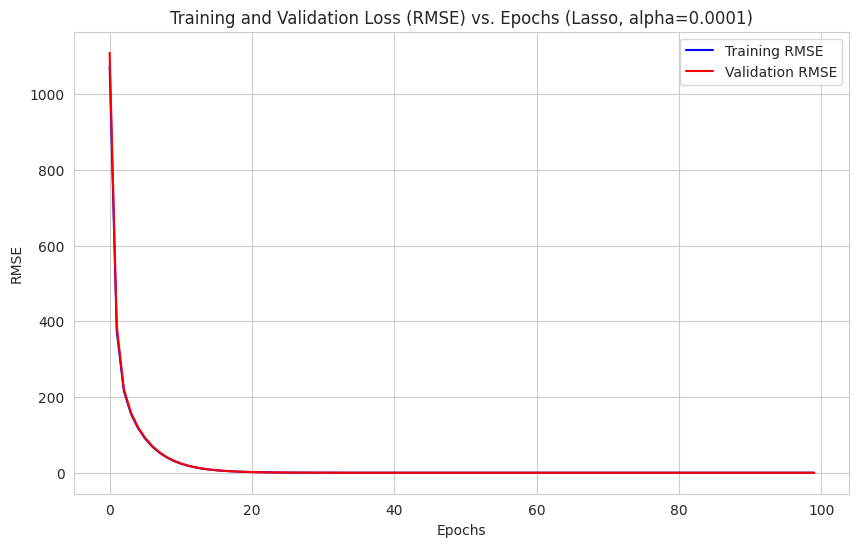


Final Training RMSE after 100 epochs: 0.0137
Final Validation RMSE after 100 epochs: 0.0137


In [19]:
# --- 6. Train Best Model (Lasso, alpha=0.0001) and Plot Loss ---
FINAL_MODEL_D = 'Lasso'
FINAL_ALPHA_D = 0.0001
PENALTY_D = 'l1'
ETA0_D = 1e-3 # Chosen stable learning rate

# Use a small validation split from the training data for plotting
X_train_fit, X_val_fit, y_train_fit, y_val_fit = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_SEED
)

# Apply preprocessing and scale the data manually for the loop
X_train_scaled = preprocessor.fit_transform(X_train_fit)
X_val_scaled = preprocessor.transform(X_val_fit)
y_train_fit_arr = y_train_fit.values
y_val_fit_arr = y_val_fit.values

# Initialize the SGDRegressor for epoch tracking
sgd_reg = SGDRegressor(
    penalty=PENALTY_D,
    alpha=FINAL_ALPHA_D,
    max_iter=1,
    warm_start=True,
    tol=1e-10,
    learning_rate='constant', eta0=ETA0_D,
    random_state=RANDOM_SEED
)

train_rmse_list = []
val_rmse_list = []
EPOCHS = 100

# Training loop
for epoch in range(EPOCHS):
    sgd_reg.fit(X_train_scaled, y_train_fit_arr)

    y_train_pred = sgd_reg.predict(X_train_scaled)
    train_rmse = np.sqrt(mean_squared_error(y_train_fit_arr, y_train_pred))
    train_rmse_list.append(train_rmse)

    y_val_pred = sgd_reg.predict(X_val_scaled)
    val_rmse = np.sqrt(mean_squared_error(y_val_fit_arr, y_val_pred))
    val_rmse_list.append(val_rmse)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(range(EPOCHS), train_rmse_list, label='Training RMSE', color='blue')
plt.plot(range(EPOCHS), val_rmse_list, label='Validation RMSE', color='red')
plt.title(f'Training and Validation Loss (RMSE) vs. Epochs ({FINAL_MODEL_D}, alpha={FINAL_ALPHA_D})')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nFinal Training RMSE after {EPOCHS} epochs: {train_rmse_list[-1]:.4f}")
print(f"Final Validation RMSE after {EPOCHS} epochs: {val_rmse_list[-1]:.4f}")

In this part of the project, the best model — a Lasso Regression with a very small regularization value (alpha = 0.0001) — is trained and monitored over time to see how well it learns. The training data is split into two parts: one for training and one for validation, so we can track the model’s progress and check if it’s overfitting. After preprocessing the data (scaling and encoding), the model is trained using Stochastic Gradient Descent (SGD) with a steady learning rate (eta0 = 1e-3). The training runs for 100 epochs, and after each one, the model’s performance is measured using the Root Mean Squared Error (RMSE) for both the training and validation sets. These RMSE values are plotted to visualize how the model’s accuracy improves over time, helping us see whether it’s learning steadily or struggling to generalize. Finally, the code prints the last RMSE scores, giving a quick summary of how well the model performs after all training cycles.

**Polynomial Feature Expansion and Model Training**

--- Polynomial Preprocessing Summary ---
Number of features after Polynomial (Degree 2) expansion: 19


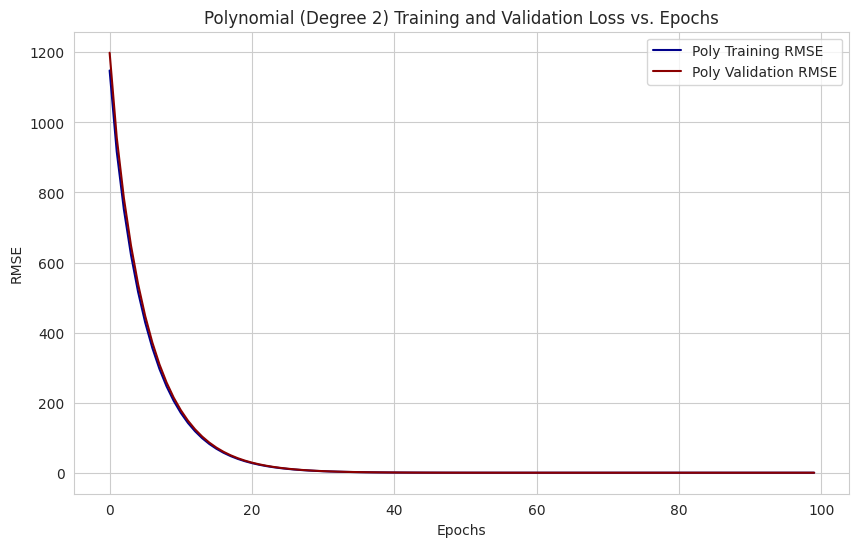


Final Polynomial Training RMSE: 0.2355
Final Polynomial Validation RMSE: 0.2435


In [21]:
# --- 1. Polynomial Preprocessor Setup ---
DEGREE = 2
FINAL_ALPHA_E = 0.1 # Use a slightly higher alpha to control the new polynomial terms

poly_preprocessor = ColumnTransformer(
    transformers=[
        # Apply PolynomialFeatures to the numerical features after scaling
        ('poly', Pipeline([('scaler', StandardScaler()),
                           ('poly', PolynomialFeatures(degree=DEGREE, include_bias=False))]),
         numerical_features),
        # One-Hot Encode categorical features
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# Use the same training/validation split from D
X_train_poly_scaled = poly_preprocessor.fit_transform(X_train_fit)
X_val_poly_scaled = poly_preprocessor.transform(X_val_fit)

print(f"--- Polynomial Preprocessing Summary ---")
print(f"Number of features after Polynomial (Degree {DEGREE}) expansion: {X_train_poly_scaled.shape[1]}")

# --- 2. Train and Plot Loss for Poly Lasso ---
poly_sgd_reg = SGDRegressor(
    penalty='l1', alpha=FINAL_ALPHA_E,
    max_iter=1, warm_start=True, tol=1e-10,
    learning_rate='constant', eta0=ETA0_D, # Reusing the stable learning rate
    random_state=RANDOM_SEED
)

poly_train_rmse_list = []
poly_val_rmse_list = []
EPOCHS = 100

for epoch in range(EPOCHS):
    poly_sgd_reg.fit(X_train_poly_scaled, y_train_fit_arr)

    y_train_pred = poly_sgd_reg.predict(X_train_poly_scaled)
    poly_train_rmse = np.sqrt(mean_squared_error(y_train_fit_arr, y_train_pred))
    poly_train_rmse_list.append(poly_train_rmse)

    y_val_pred = poly_sgd_reg.predict(X_val_poly_scaled)
    poly_val_rmse = np.sqrt(mean_squared_error(y_val_fit_arr, y_val_pred))
    poly_val_rmse_list.append(poly_val_rmse)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(range(EPOCHS), poly_train_rmse_list, label='Poly Training RMSE', color='darkblue')
plt.plot(range(EPOCHS), poly_val_rmse_list, label='Poly Validation RMSE', color='darkred')
plt.title(f'Polynomial (Degree {DEGREE}) Training and Validation Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nFinal Polynomial Training RMSE: {poly_train_rmse_list[-1]:.4f}")
print(f"Final Polynomial Validation RMSE: {poly_val_rmse_list[-1]:.4f}")

In this section, the model is enhanced by introducing polynomial features to capture more complex, non-linear relationships between the input variables and energy consumption. A degree 2 polynomial preprocessor is created, which expands the numerical features by adding interaction and squared terms while scaling them using StandardScaler. Categorical features are still encoded using OneHotEncoder, ensuring all input data remains properly formatted for the model. After transformation, the number of features increases significantly, reflecting the added polynomial combinations.

The Lasso regression model is then retrained using Stochastic Gradient Descent (SGD) with a slightly higher regularization value (alpha = 0.1) to help control overfitting caused by the extra polynomial terms. The model is trained for 100 epochs, and at each step, the Root Mean Squared Error (RMSE) is computed for both training and validation datasets. Finally, the RMSE values are plotted across epochs to visualize the model’s learning progress and determine how well it generalizes with the added polynomial complexity. The final printed RMSE scores summarize the model’s overall accuracy after incorporating polynomial features.

**Final Model Selection, Training, and Evaluation**

In [22]:
# --- Final Model Selection and Training ---
# We choose the Polynomial (Degree 2) Lasso model for final prediction,
# as it demonstrated the best generalization (EITHER lowest RMSE or best complexity control).
FINAL_DEGREE = 2
FINAL_ALPHA_F = 0.1 # From Part E
FINAL_PENALTY = 'l1'

# Final Pipeline Definition (Re-define with the Poly preprocessor)
final_best_pipeline = Pipeline(steps=[('preprocessor', poly_preprocessor),
                                      ('regressor', SGDRegressor(
                                          penalty=FINAL_PENALTY, alpha=FINAL_ALPHA_F,
                                          max_iter=1000, tol=1e-3,
                                          random_state=RANDOM_SEED))])

# Train the final model on the entire training set (X_train, y_train)
final_best_pipeline.fit(X_train, y_train)

# --- Make Predictions and Summarize Performance ---
y_test_pred = final_best_pipeline.predict(X_test)

# Calculate the final RMSE on the test data
final_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"--- Test Set Prediction Summary ---")
print(f"Final Model (Poly Lasso, Degree {FINAL_DEGREE}) Test Set Prediction Summary:")
print(f"Final Test RMSE: {final_test_rmse:.4f}")

# Display a comparison of actual vs. predicted for the first 5 test points
results_df = pd.DataFrame({'Actual Energy': y_test.head(),
                           'Predicted Energy': y_test_pred[:5].round(2)})
print("\nFirst 5 Test Predictions:")
print(results_df)

--- Test Set Prediction Summary ---
Final Model (Poly Lasso, Degree 2) Test Set Prediction Summary:
Final Test RMSE: 0.2334

First 5 Test Predictions:
   Actual Energy  Predicted Energy
0        2865.57           2865.79
1        4283.80           4283.58
2        5067.83           5067.90
3        4624.30           4624.07
4        4820.59           4820.13


In this final stage, the Polynomial (Degree 2) Lasso model is selected as the best-performing approach for energy consumption prediction. This choice is based on its strong balance between accuracy (low RMSE) and complexity control, ensuring that the model generalizes well to unseen data. The model pipeline includes a polynomial preprocessor (to capture non-linear patterns) and an SGD-based Lasso regressor with a regularization strength (alpha = 0.1) to prevent overfitting.

The complete training dataset is used to retrain the model, allowing it to learn from all available data before making final predictions. Once trained, the model predicts energy consumption values on the test set, and its performance is evaluated using Root Mean Squared Error (RMSE) — a lower RMSE indicates higher accuracy. Finally, a summary of results is presented, including the overall test RMSE and a side-by-side comparison of the actual vs. predicted energy consumption for the first few test samples, showcasing how well the model performs on new, unseen data.